In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/home/deve/myenv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
mu = 5
lamda = 40
def g(x,y):  #derivative function for euler and rk4
    return np.asarray([y[1], mu*(1 - y[0]**2)*y[1] - lamda*y[0] ])

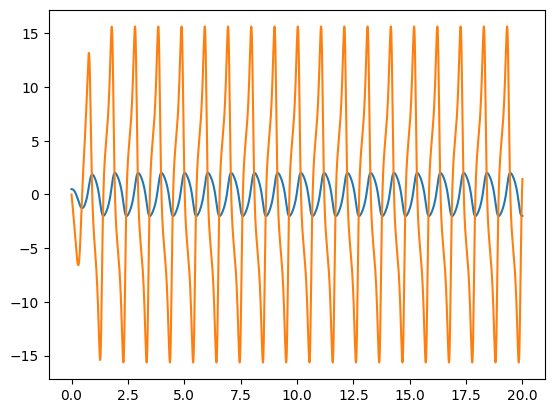

In [3]:
#Q1

#functions 
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-4
x0 = 0.0
xf = 20

xs = np.arange(x0, xf, h)
N = len(xs)

y_ini = np.asarray([0.5, 0])  # Initial condition 
y_rk4 = caller_rk(rk4, g, y_ini, N, xs, h)

plt.plot(xs, y_rk4)

In [4]:
#Q2

# Dormand-Prince
a2 = 1/5;  b21 = 1/5;
a3 = 3/10; b31 = 3/40;       b32 = 9/40;
a4 = 4/5;  b41 = 44/45;      b42 = -56/15;      b43 = 32/9;
a5 = 8/9;  b51 = 19372/6561; b52 = -25360/2187; b53 = 64448/6561; b54 =-212/729;
a6 = 1;    b61 = 9017/3168;  b62 = -355/33;     b63 = 46732/5247; b64 = 49/176;  b65 = -5103/18656;
a7 = 1;    b71 = 35/384;     b72 = 0;           b73 = 500/1113;   b74 = 125/192; b75 = -2187/6784;  b76 = 11/84;

c1 = 35/384; c2 = 0; c3 = 500/1113; c4 = 125/192; c5=-2187/6784; c6 = 11/84; c7 = 0;
c1s = 5179/57600; c2s = 0; c3s = 7571/16695; c4s = 393/640; c5s = -92097/339200; c6s = 187/2100; c7s = 1/40;

# Embedded Runge-Kutta formulas
def erk54h(f, x, y, h, k7bh):
    # Implement FSAL (first same as last)
    # The first
    # k1 = k7bh, unless k1 is zero (initially)
    if sum(k7bh)==0: 
        k1 = h*f(x, y)
    else:
        k1 = k7bh*h

    # Implement rest of the Butcher table
    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)

    # get y fifth-order correct
    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6 # c7 = 0     
    
    # FSAL -> the last
    k7bh = f(x + a7*h, y5)

    # get y fourth-order correct
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7bh*h

    # return y, error, k7bh
    err = abs(y5 - y4)
    return y5, err, k7bh

def caller54(fn, y_ini, x0, xT, h0, max_iter, abstol, reltol):
    y = np.asarray(y_ini); 
    h = h0;
    ys = np.zeros((max_iter, len(y_ini)))
    xs = np.zeros((max_iter, 1))
    xs[0] = x0 
    ys[0,:] = y
    x = x0
    i = 0 
    k = 1
    k7bh = np.zeros(len(y_ini))
    while x<=xT and i<max_iter:
        
        # calculate the tolerance
        tol = abstol + reltol*np.linalg.norm(ys[i,:])
        
        # get the next y and the error
        y, err, k7bh = erk54h(fn,xs[i],ys[i,:],h, k7bh)
        
        # get max error and the scale factor
        merr = np.max(err)
        if merr == 0.0: 
            merr = tol/100

        hnew = 0.9*h*(tol/merr)**0.2
        
        if merr<tol and h/5<hnew<5*h:   
            x += h
            i += 1
            xs[i] = x
            ys[i,:] = y
        
        # anyway we update h every time
        h = hnew
    
    # if the maximum number of steps exceeded
    if i>=max_iter:
        println(i," Increase max_iter.")
        return None
    print(f"The number of time steps required is {i}")
    return xs[1:i-1], ys[1:i-1,:]

In [5]:
# Initialize parameters
max_iter = 20000
abstol = 1.0e-6
reltol = 1.0e-8
y_ini = [0.5,0]
t0 = 0.0
tf = 20.0
h0 = 1e-4

# Final call 
ts54, ys54 = caller54(g, y_ini, t0, tf, h0, max_iter, abstol, reltol)

The number of time steps required is 17115


In [6]:
print(ts54.shape, ys54.shape)

(17113, 1) (17113, 2)


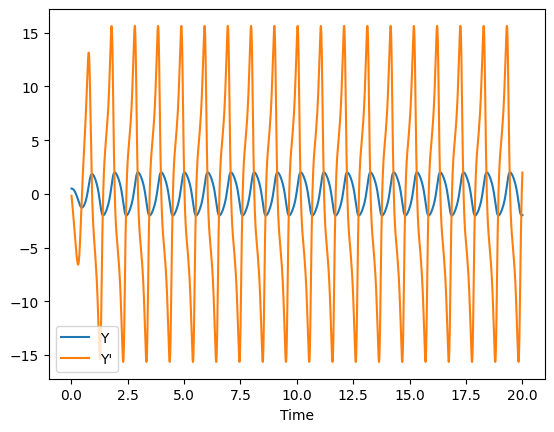

In [7]:
plt.plot(ts54, ys54[:,0], label = "Y")
plt.plot(ts54, ys54[:,1], label = "Y'")
plt.xlabel("Time")
plt.legend()
plt.show()

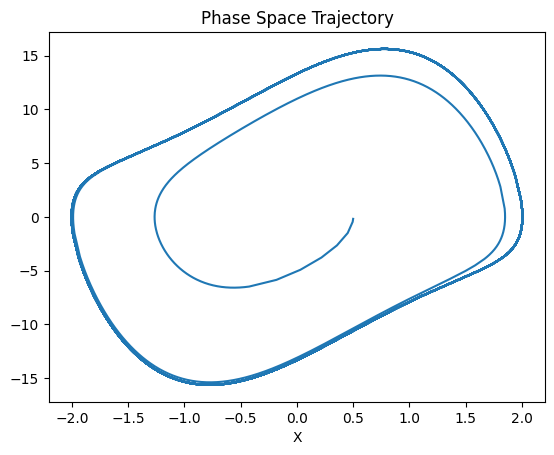

In [8]:
#Q3
plt.plot(ys54[:,0], ys54[:,1])
plt.title("Phase Space Trajectory")
plt.xlabel("X")
plt.show()